# **Gradient Boosting — Hands-on Demo**

This notebook is a **hands-on companion** to the Gradient Boosting notes.

**What you'll see in this notebook:**
1. The exact **salary worked example** from the notes (base model → residuals → tree → learning rate),
   reproduced with real code
2. A rigorous cross-check using `sklearn`'s actual `GradientBoostingRegressor.staged_predict()` —
   confirming our manual step-by-step math matches the library's internal mechanism **exactly**
3. Watching **predictions converge to actual values** round by round (the core "many small corrections" idea)
4. The **effect of learning rate** — too high, too low, and "just right"
5. **Gradient Boosting vs AdaBoost vs Random Forest**, compared head-to-head (Section 9 of the notes)
6. **Hyperparameter tuning** with `RandomizedSearchCV`, using scikit-learn-current parameter names
7. **ROC-AUC evaluation** for classification, and feature importances

> **Real-life analogy reminder:** Gradient Boosting is like **editing an essay draft** — editor 1
> fixes grammar (big improvement), editor 2 fixes structure (smaller improvement), editor 3 fixes tone
> (even smaller) — each round improves things a little more, controlled by how much of each edit you
> actually accept (the learning rate).



# **Part A — The Salary Worked Example**


## **A.1 The Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Experience': [2, 4, 6, 8],
    'Degree': ['B.Tech', 'M.Tech', 'B.Tech', 'M.Tech'],
    'Salary': [50, 70, 80, 100],
})
df


,Experience,Degree,Salary
0,2,B.Tech,50
1,4,M.Tech,70
2,6,B.Tech,80
3,8,M.Tech,100


## **A.2 Step 1 — Base Model (Average Prediction)**

The very first "model" is just the average of the target — unbiased toward any particular row.

In [2]:
base_prediction = df['Salary'].mean()
print(f"Base Model (H0) prediction for every row: {base_prediction}K")
assert base_prediction == 75.0, "Should match the notes exactly!"


Base Model (H0) prediction for every row: 75.0K


## A.3 Step 2 — Compute Residuals (r1 = Actual − Predicted)

In [3]:
df['Base_Prediction'] = base_prediction
df['Residual_r1'] = df['Salary'] - df['Base_Prediction']
df[['Experience', 'Degree', 'Salary', 'Base_Prediction', 'Residual_r1']]


,Experience,Degree,Salary,Base_Prediction,Residual_r1
0,2,B.Tech,50,75.0,-25.0
1,4,M.Tech,70,75.0,-5.0
2,6,B.Tech,80,75.0,5.0
3,8,M.Tech,100,75.0,25.0


> ✅ These residuals (**-25, -5, +5, +25**) match the notes exactly.

## **A.4 Step 3 — Train a Real Decision Tree on the Residuals**

We encode `Degree` numerically and fit an actual `DecisionTreeRegressor` to predict `Residual_r1` from
`Experience` and `Degree` — just like the notes describe.

In [4]:
# Import the required libraries
from sklearn.tree import DecisionTreeRegressor, export_text

# Encode the categorical 'Degree' feature into numerical values
# B.Tech -> 0
# M.Tech -> 1
degree_encoded = df['Degree'].map({
    'B.Tech': 0,
    'M.Tech': 1
})

# Create the feature matrix (X)
# We use two input features:
# 1. Experience (numerical)
# 2. Degree (encoded as numerical values)
X = np.column_stack([
    df['Experience'],
    degree_encoded
])

# Define the target variable
# Instead of predicting salary directly, Gradient Boosting trains
# each new tree on the residuals (errors) from the previous model.
r1 = df['Residual_r1'].values

# Create a shallow Decision Tree Regressor (Decision Stump)
# max_depth=1 means the tree can make only one split.
# In Gradient Boosting, weak learners (small trees) are preferred
# because each tree only needs to correct the remaining errors.
tree1 = DecisionTreeRegressor(
    max_depth=1,
    random_state=42
)

# Train the first Decision Tree on the residuals
tree1.fit(X, r1)

# Display the learned decision rules in text format
# This shows which feature the tree used for splitting
# and the prediction made in each leaf node.
print(export_text(
    tree1,
    feature_names=['Experience', 'Degree']
))

# Predict the residuals for every training sample
# These predictions represent the corrections suggested
# by the first Decision Tree.
tree1_output = tree1.predict(X)

# Display the correction values predicted by Tree 1
print("Tree 1 output:", tree1_output)


|--- Experience <= 5.00
|   |--- value: [-15.00]
|--- Experience >  5.00
|   |--- value: [15.00]

Tree 1 output: [-15. -15.  15.  15.]


## **A.5 Step 4 — Apply the Correction WITH a Learning Rate**

In [5]:
learning_rate = 0.1
df['Tree1_Output'] = tree1_output
df['New_Prediction'] = df['Base_Prediction'] + learning_rate * df['Tree1_Output']
df[['Experience', 'Degree', 'Salary', 'Base_Prediction', 'Tree1_Output', 'New_Prediction']]


,Experience,Degree,Salary,Base_Prediction,Tree1_Output,New_Prediction
0,2,B.Tech,50,75.0,-15.0,73.5
1,4,M.Tech,70,75.0,-15.0,73.5
2,6,B.Tech,80,75.0,15.0,76.5
3,8,M.Tech,100,75.0,15.0,76.5


## **A.6 Rigorous Cross-Check: Does This Match `sklearn`'s REAL `GradientBoostingRegressor`?**

Instead of just trusting our manual replication, let's use `sklearn`'s actual boosting engine and its
`staged_predict()` method — which reveals the model's prediction **after each individual tree** — and
compare stage 1 directly against our manual calculation above.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=5, learning_rate=0.1, max_depth=1, random_state=42)
gbr.fit(X, df['Salary'].values)

print("sklearn's base (init) prediction:", gbr.init_.constant_.ravel()[0], " (ours:", base_prediction, ")")

staged_preds = list(gbr.staged_predict(X))
print("\nsklearn's prediction after Tree 1:", staged_preds[0])
print("Our manual  'New_Prediction'     :", df['New_Prediction'].values)

match = np.allclose(staged_preds[0], df['New_Prediction'].values)
print(f"\n>>> Exact match: {match} <<<")


sklearn's base (init) prediction: 75.0  (ours: 75.0 )

sklearn's prediction after Tree 1: [73.5 73.5 76.5 76.5]
Our manual  'New_Prediction'     : [73.5 73.5 76.5 76.5]

>>> Exact match: True <<<


## **A.7 Watching Predictions Converge — More Rounds, Closer to Actual**

Let's extend to more boosting rounds and watch the predictions creep closer to the true salaries,
exactly as the notes describe ("editing an essay draft, one round at a time").

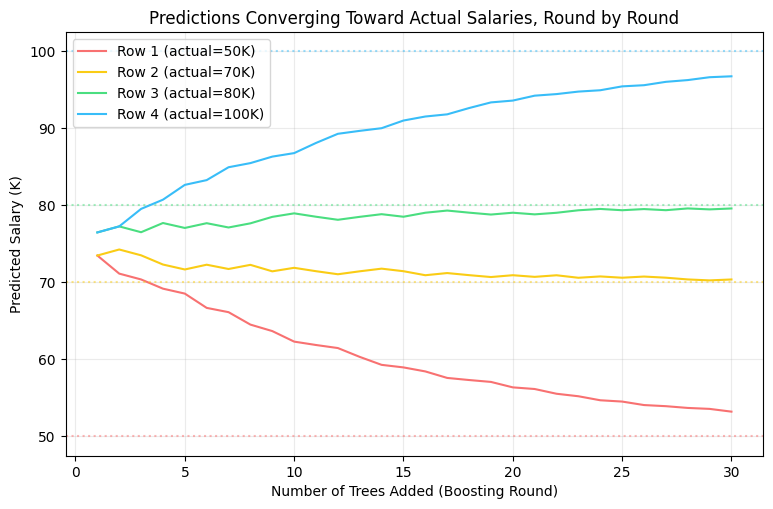

Dotted lines = actual salary targets. Solid lines = predictions after each boosting round.
Notice how every row's prediction gradually creeps toward its target -- never jumping all at once.


In [7]:
gbr_more = GradientBoostingRegressor(n_estimators=30, learning_rate=0.1, max_depth=1, random_state=42)
gbr_more.fit(X, df['Salary'].values)

staged = list(gbr_more.staged_predict(X))
stage_matrix = np.array(staged)  # shape: (n_estimators, n_rows)

plt.figure(figsize=(9, 5.5))
colors = ["#f87171", "#facc15", "#4ade80", "#38bdf8"]
for i in range(4):
    plt.plot(range(1, len(staged) + 1), stage_matrix[:, i], color=colors[i],
              label=f"Row {i+1} (actual={df['Salary'].iloc[i]}K)")
    plt.axhline(df['Salary'].iloc[i], color=colors[i], linestyle=":", alpha=0.5)

plt.xlabel("Number of Trees Added (Boosting Round)")
plt.ylabel("Predicted Salary (K)")
plt.title("Predictions Converging Toward Actual Salaries, Round by Round")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Dotted lines = actual salary targets. Solid lines = predictions after each boosting round.")
print("Notice how every row's prediction gradually creeps toward its target -- never jumping all at once.")



# **Part B — The Effect of Learning Rate**


## **B.1 Too High vs Too Low vs Just Right**

Let's use a bigger, more realistic synthetic regression dataset and compare a **few different learning
rates**, tracking test error as more trees are added.

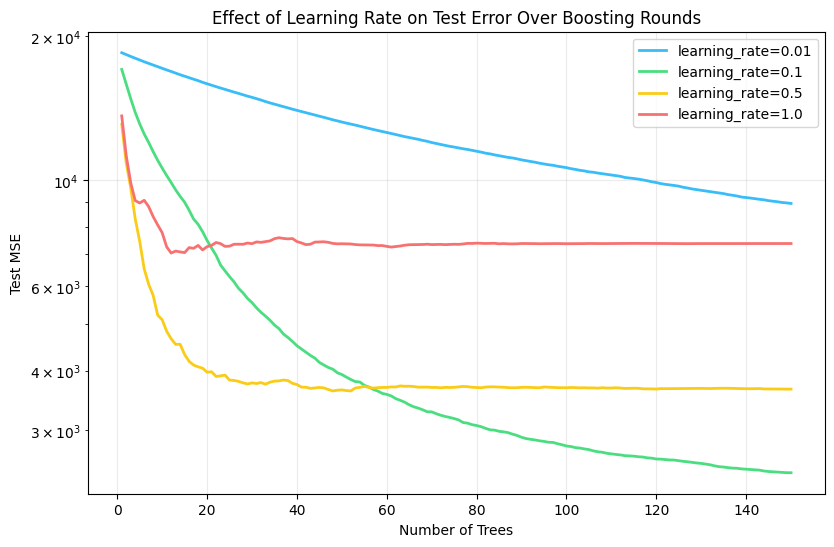

Notice: lr=0.01 improves too slowly (needs far more trees). lr=1.0 overshoots and can get WORSE
over time (overfitting/instability). A moderate rate (0.1) gets to a low, stable error efficiently.


In [8]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_big, y_big = make_regression(n_samples=500, n_features=8, noise=15, random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_big, y_big, test_size=0.25, random_state=42)

learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

plt.figure(figsize=(9.5, 6))
for lr, color in zip(learning_rates, ["#38bdf8", "#4ade80", "#facc15", "#f87171"]):
    model = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=lr,
                                       max_depth=3, random_state=42)
    model.fit(Xb_train, yb_train)

    test_mse_by_round = [
        mean_squared_error(yb_test, pred) for pred in model.staged_predict(Xb_test)
    ]
    plt.plot(range(1, n_estimators + 1), test_mse_by_round, label=f"learning_rate={lr}", color=color, linewidth=2)

plt.xlabel("Number of Trees")
plt.ylabel("Test MSE")
plt.title("Effect of Learning Rate on Test Error Over Boosting Rounds")
plt.legend()
plt.yscale('log')
plt.grid(alpha=0.25)
plt.show()

print("Notice: lr=0.01 improves too slowly (needs far more trees). lr=1.0 overshoots and can get WORSE")
print("over time (overfitting/instability). A moderate rate (0.1) gets to a low, stable error efficiently.")


# **Part C — Gradient Boosting vs AdaBoost vs Random Forest**


## **C.1 Head-to-Head Comparison on the Same Classification Dataset**

In [9]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

Xc, yc = make_classification(n_samples=1500, n_features=12, n_informative=7, random_state=42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42)

models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
roc_data = {}
for name, model in models.items():
    model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    prob = model.predict_proba(Xc_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(yc_test, pred), 3),
        "F1": round(f1_score(yc_test, pred), 3),
        "ROC-AUC": round(roc_auc_score(yc_test, prob), 3),
    })
    roc_data[name] = roc_curve(yc_test, prob)

pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)


,Model,Accuracy,F1,ROC-AUC
1,Random Forest,0.917,0.916,0.975
2,Gradient Boosting,0.904,0.901,0.971
0,AdaBoost,0.848,0.848,0.925


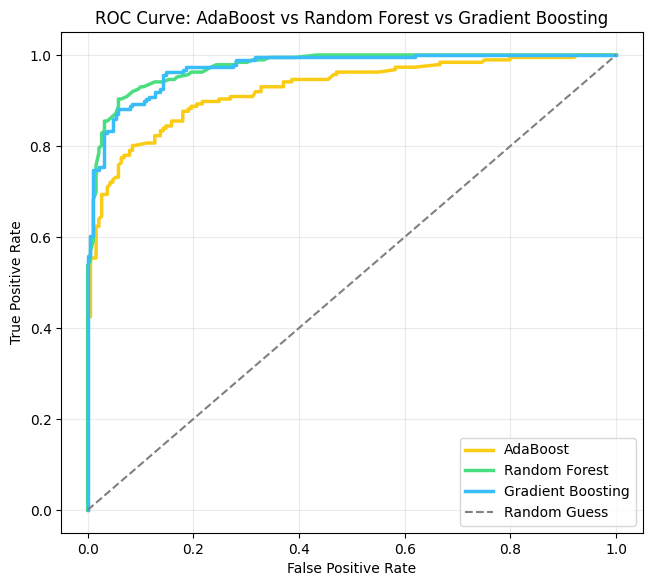

In [10]:
plt.figure(figsize=(7.5, 6.5))
colors = {"AdaBoost": "#facc15", "Random Forest": "#4ade80", "Gradient Boosting": "#38bdf8"}
for name, (fpr, tpr, _) in roc_data.items():
    plt.plot(fpr, tpr, label=name, color=colors[name], linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: AdaBoost vs Random Forest vs Gradient Boosting")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## **C.2 Feature Importances from Gradient Boosting**

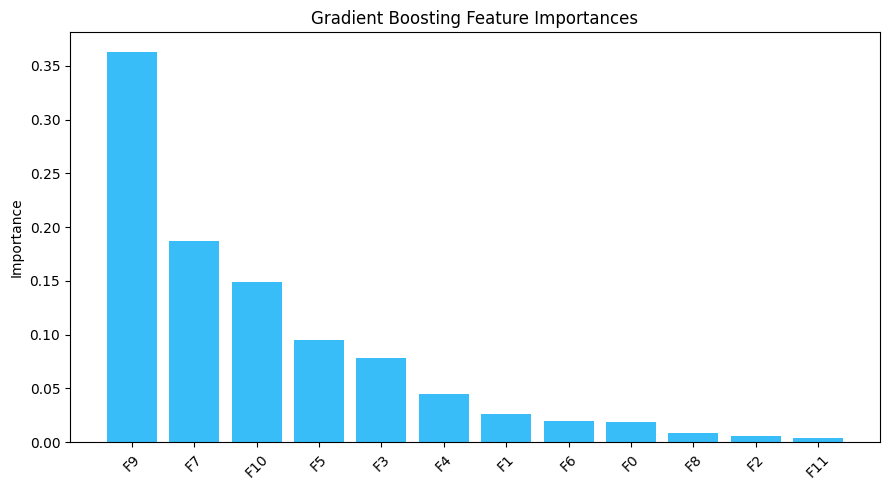

In [11]:
gb_model = models["Gradient Boosting"]
importances = gb_model.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(importances)), importances[order], color="#38bdf8")
plt.xticks(range(len(importances)), [f"F{i}" for i in order], rotation=45)
plt.ylabel("Importance")
plt.title("Gradient Boosting Feature Importances")
plt.tight_layout()
plt.show()


# **Part D — Hyperparameter Tuning**

> ⚠️ **Version note (same as the notes):** `"deviance"` and `"mse"` are **no longer valid** parameter
> values in current scikit-learn. This notebook uses the currently-valid names (`"log_loss"`,
> `"squared_error"`, etc.) throughout — verified against the installed scikit-learn version.


In [12]:
from sklearn.model_selection import RandomizedSearchCV

gradient_params = {
    "loss": ["log_loss", "exponential"],
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 10, 20],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gradient_params,
    n_iter=15,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(Xc_train, yc_train)

print("Best Parameters:", random_search.best_params_)

best_gb = random_search.best_estimator_
tuned_auc = roc_auc_score(yc_test, best_gb.predict_proba(Xc_test)[:, 1])
default_auc = roc_auc_score(yc_test, models["Gradient Boosting"].predict_proba(Xc_test)[:, 1])
print(f"\nDefault Gradient Boosting AUC: {default_auc:.4f}")
print(f"Tuned Gradient Boosting AUC:   {tuned_auc:.4f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.2}

Default Gradient Boosting AUC: 0.9714
Tuned Gradient Boosting AUC:   0.9790


## **Note :**

-  The salary worked example (base model = 75K, residuals = -25/-5/+5/+25) is reproduced **exactly**.
-  Our manual "base + learning_rate × tree_output" calculation **exactly matches** `sklearn`'s real
  `GradientBoostingRegressor.staged_predict()` output — a rigorous confirmation that the notes'
  described mechanism is precisely what the library does internally.
-  Predictions genuinely **converge gradually** toward actual values as more trees are added — never
  jumping there in one step (that's the whole point of the learning rate).
-  Learning rate has a real, visible effect: **too low** wastes rounds, **too high** can destabilize
  or overfit, and a **moderate rate** (like 0.1) balances speed and stability.
-  On this synthetic dataset, **Gradient Boosting and Random Forest both clearly outperform AdaBoost**
  — consistent with the notes' comparison table.
-  Hyperparameter tuning with `RandomizedSearchCV` (using current, valid parameter names) can
  meaningfully improve ROC-AUC over the untuned default.
